<a href="https://colab.research.google.com/github/KiaNoForte/Cryptography/blob/main/CryptoLab02_Math_and_Randomness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crypto Lab 02: Mathematical Foundations and Randomness

**CYBR 3570 - Applied Cryptography**  
**Toolkit Version:** `v0.2`

## Today's Big Question

**Why does cryptography need both mathematical structure and unpredictability?**

This week, your toolkit gains reusable math utilities and randomness utilities.

## Learning Objectives

By the end of this notebook, you should be able to compute modular operations, use GCDs and modular inverses, calculate simple entropy values, distinguish `random` from `secrets`, and demonstrate modulo bias.

## Setup

In [1]:
from __future__ import annotations

import math
import random
import secrets
from collections import Counter
from typing import Iterable

import matplotlib.pyplot as plt

## Part 1: Modular Arithmetic

Modular arithmetic is arithmetic with wraparound. In Python, `%` computes a remainder.

In [2]:
print(42 % 9)
print(-1 % 26)
print(27 % 26)

6
25
1


### Exercise 1.1: Modular Reduction

In [3]:
def mod_reduce(a: int, m: int) -> int:
    if m <= 0:
        raise ValueError("modulus must be positive")
    # TODO: return the least nonnegative residue of a modulo m
    return a % m

assert mod_reduce(42, 9) == 6
assert mod_reduce(-1, 26) == 25
assert mod_reduce(27, 26) == 1

### Exercise 1.2: Modular Operations

In [4]:
def mod_add(a: int, b: int, m: int) -> int:
    # TODO
    return (a + b) % m


def mod_mul(a: int, b: int, m: int) -> int:
    # TODO
    return (a * b) % m


def mod_pow(base: int, exponent: int, modulus: int) -> int:
    if exponent < 0:
        raise ValueError("negative exponents are not supported here")
    # TODO: use Python's efficient modular exponentiation
    return pow(base, exponent, modulus)

assert mod_add(8, 4, 9) == 3
assert mod_mul(6, 8, 9) == 3
assert mod_pow(3, 8, 7) == 2

### Reflection 1

Why is `pow(base, exponent, modulus)` preferable to computing `base ** exponent` and reducing afterward when the numbers are very large?

**Your answer:**

This applies the modulo rule at every step which keeps the numbers small and manageable. Using the base method would cause massive numbers, be completely slow and the efficency is a shortcut which works with small numbers and making it fast and memory family

## Part 2: GCDs and Modular Inverses

A modular inverse of `a` modulo `m` is a number `x` such that `a*x == 1 mod m`. A modular inverse exists exactly when `gcd(a, m) = 1`.

In [7]:
def gcd(a: int, b: int) -> int:
    a, b = abs(a), abs(b)
    while b != 0:
        # TODO: update a and b
        a, b = b, a % b
    return a

assert gcd(15, 26) == 1
assert gcd(14, 26) == 2
assert gcd(0, 5) == 5

### Exercise 2.1: Extended GCD

In [6]:
def extended_gcd(a: int, b: int) -> tuple[int, int, int]:
    old_r, r = a, b
    old_s, s = 1, 0
    old_t, t = 0, 1
    while r != 0:
        quotient = old_r // r
        old_r, r = r, old_r - quotient * r
        old_s, s = s, old_s - quotient * s
        old_t, t = t, old_t - quotient * t
    return old_r, old_s, old_t

g, x, y = extended_gcd(15, 26)
print(g, x, y, 15*x + 26*y)
assert g == 1
assert 15*x + 26*y == g

1 7 -4 1


### Exercise 2.2: Modular Inverse

In [8]:
def mod_inverse(a: int, m: int) -> int:
    g, x, _ = extended_gcd(a, m)
    if g != 1:
        raise ValueError(f"{a} has no inverse modulo {m}")
    return x % m

assert mod_inverse(3, 26) == 9
assert mod_inverse(15, 26) == 7

try:
    mod_inverse(14, 26)
except ValueError as e:
    print("Expected error:", e)

Expected error: 14 has no inverse modulo 26


## Part 3: Affine Cipher Connection

The affine cipher encrypts letters using `y = ax + b mod 26`. To decrypt, we need `x = a^-1(y-b) mod 26`.

In [9]:
ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def char_to_num(ch: str) -> int:
    return ALPHABET.index(ch.upper())

def num_to_char(n: int) -> str:
    return ALPHABET[n % 26]

def affine_encrypt_char(ch: str, a: int, b: int) -> str:
    x = char_to_num(ch)
    y = (a * x + b) % 26
    return num_to_char(y)

def affine_decrypt_char(ch: str, a: int, b: int) -> str:
    y = char_to_num(ch)
    inv_a = mod_inverse(a, 26)
    x = inv_a * (y - b) % 26
    return num_to_char(x)

cipher = ''.join(affine_encrypt_char(c, 9, 13) for c in "ATTACK")
plain = ''.join(affine_decrypt_char(c, 9, 13) for c in cipher)
print(cipher, plain)

NCCNFZ ATTACK


### Reflection 2

Why is `a = 14` not a valid affine cipher multiplier modulo 26?

**Your answer:**

So this is invalid because the gcd 14,26 = 2 =/ 1. To be a valid multiplier in an affine cipher. a and the alphabet size (m = 26) must be coprime or their greatest common divisor must be 1. It'll break the decryption because their is no modular inverse along with information loss. Itll cause multiple plaintexts to map to the same ciphertext letter and making decryption impossible

## Part 4: Random-Looking vs Randomly Generated

The string `11010110` may look more random than `00000000`, but if both are possible outputs of a uniform 8-bit generator, each has probability `1/256`. Randomness is about the process, not just the appearance.

In [10]:
values = [secrets.randbits(8) for _ in range(10)]
print([format(v, '08b') for v in values])

['00101100', '00010000', '01001000', '01100111', '11000001', '10010010', '01100011', '11100011', '10101001', '10010010']


### Reflection 3

Suppose a secure generator outputs `00000000`. Should we immediately conclude the generator is broken? Explain.

**Your answer:**

Yeah goodness no. We shouldn't conclude the generator is broken. In a truly random generator every combo has the exact probability percantage. Rejecting the 0's would make it look like the generator comes in as non random. Though, to suspect a break is to see if th 0's appear repeatedly across many consecutive runs

## Part 5: Entropy

Entropy measures uncertainty in a probability distribution: `H = -sum(p * log2(p))`. A fair coin has 1 bit of entropy. A biased coin has less.

In [ ]:
def entropy(probabilities: Iterable[float]) -> float:
    total = 0.0
    for p in probabilities:
        if p < 0:
            raise ValueError("probabilities cannot be negative")
        if p == 0:
            continue
        total -= p * math.log2(p)
    return total

print("Fair coin:", entropy([0.5, 0.5]))
print("Biased coin:", entropy([0.25, 0.75]))
print("Very biased coin:", entropy([0.01, 0.99]))
print("Uniform byte:", entropy([1/256] * 256))

### Exercise 5.1

Compute the entropy of a fair six-sided die and a loaded die with probabilities `[0.5, 0.1, 0.1, 0.1, 0.1, 0.1]`.

In [ ]:
fair_die_entropy = entropy([1/6] * 6)
loaded_die_entropy = entropy([0.5, 0.1, 0.1, 0.1, 0.1, 0.1])
print("Fair die entropy:", fair_die_entropy)
print("Loaded die entropy:", loaded_die_entropy)

## Part 6: Python `random` vs `secrets`

Python's `random` module is useful for simulations and testing. It is not designed for cryptographic security. For security-sensitive values, use `secrets` or a vetted cryptographic library.

In [ ]:
print("random:", [random.randint(0, 100) for _ in range(5)])
print("secrets:", [secrets.randbelow(101) for _ in range(5)])
print("token:", secrets.token_hex(16))

### Demonstration: Deterministic Seeding

In [ ]:
random.seed(3570)
first = [random.randint(0, 1000000) for _ in range(5)]
random.seed(3570)
second = [random.randint(0, 1000000) for _ in range(5)]
print(first)
print(second)
print("Same sequence?", first == second)

### Reflection 4

Why is deterministic seeding useful in scientific experiments but dangerous when generating cryptographic keys?

**Your answer:**

Deterministic seeding is great because it makes experiments reproducible. Anyone running the code with the sae seed gets the same results. Dangeruous though due to the predictability

## Part 7: Modulo Bias

Suppose we want a random decimal digit from 0 to 9. A byte has 256 possible values. If we compute `random_byte % 10`, digits 0-5 occur 26 times each while digits 6-9 occur 25 times each.

In [13]:
def biased_digit() -> int:
    return secrets.randbits(8) % 10

def unbiased_digit() -> int:
    while True:
        x = secrets.randbits(8)
        if x < 250:
            return x % 10

def sample_counts(fn, n: int = 100_000) -> Counter:
    return Counter(fn() for _ in range(n))

biased_counts = sample_counts(biased_digit)
unbiased_counts = sample_counts(unbiased_digit)
print("Biased:", biased_counts)
print("Unbiased:", unbiased_counts)

Biased: Counter({5: 10199, 1: 10175, 0: 10130, 2: 10129, 4: 10094, 3: 10083, 8: 9861, 7: 9804, 6: 9772, 9: 9753})
Unbiased: Counter({8: 10144, 2: 10069, 9: 10041, 3: 10028, 0: 10008, 1: 9989, 4: 9972, 5: 9965, 7: 9916, 6: 9868})


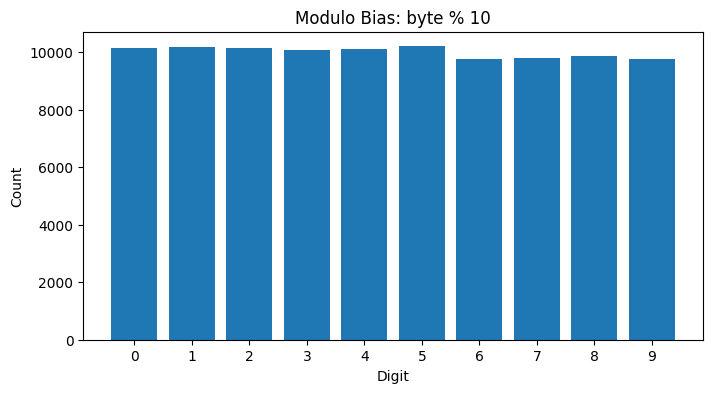

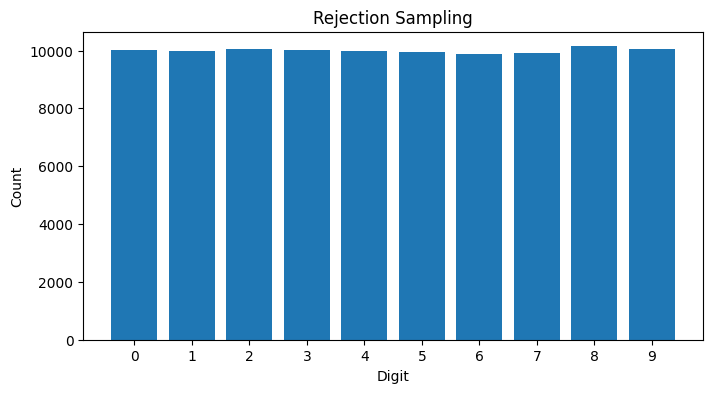

In [14]:
def plot_counts(counts: Counter, title: str) -> None:
    xs = list(range(10))
    ys = [counts[x] for x in xs]
    plt.figure(figsize=(8, 4))
    plt.bar(xs, ys)
    plt.xticks(xs)
    plt.title(title)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.show()

plot_counts(biased_counts, "Modulo Bias: byte % 10")
plot_counts(unbiased_counts, "Rejection Sampling")

### Exercise 7.1

Use `secrets.randbelow(10)` to generate unbiased random digits. Compare its distribution to rejection sampling.

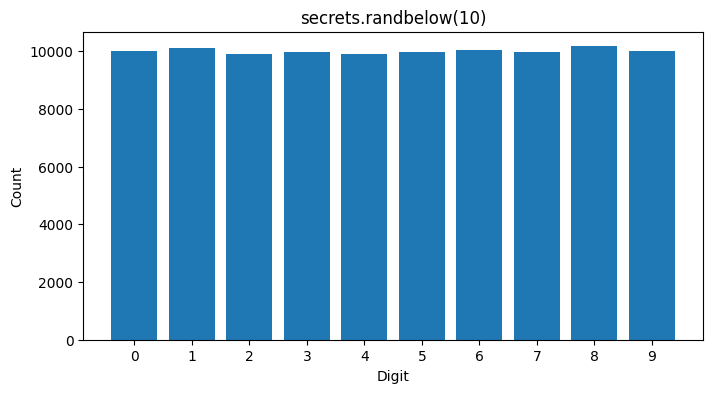

In [15]:
from collections import Counter
import matplotlib.pyplot as plt
import secrets

def sample_counts(fn, n: int = 100_000) -> Counter:
    return Counter(fn() for _ in range(n))

def plot_counts(counts: Counter, title: str) -> None:
    xs = list(range(10))
    ys = [counts[x] for x in xs]
    plt.figure(figsize=(8, 4))
    plt.bar(xs, ys)
    plt.xticks(xs)
    plt.title(title)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.show()

def secrets_digit() -> int:
    return secrets.randbelow(10)

secrets_counts = sample_counts(secrets_digit)
plot_counts(secrets_counts, "secrets.randbelow(10)")

## Part 8: Toolkit Integration

Add the following modules to your toolkit:

```text
crypto_toolkit/math/modular.py
crypto_toolkit/math/gcd.py
crypto_toolkit/utilities/randomness.py
```

Then run `python -m pytest`.

In [16]:
def mod_reduce(a: int, m: int) -> int:
    if m <= 0:
        raise ValueError("modulus must be positive")
    return a % m


def mod_add(a: int, b: int, m: int) -> int:
    return (a + b) % m


def mod_mul(a: int, b: int, m: int) -> int:
    return (a * b) % m


def mod_pow(base: int, exponent: int, modulus: int) -> int:
    if exponent < 0:
        raise ValueError("negative exponents are not supported here")
    return pow(base, exponent, modulus)

In [17]:
def gcd(a: int, b: int) -> int:
    a, b = abs(a), abs(b)
    while b != 0:
        a, b = b, a % b
    return a


def extended_gcd(a: int, b: int) -> tuple[int, int, int]:
    old_r, r = a, b
    old_s, s = 1, 0
    old_t, t = 0, 1
    while r != 0:
        quotient = old_r // r
        old_r, r = r, old_r - quotient * r
        old_s, s = s, old_s - quotient * s
        old_t, t = t, old_t - quotient * t
    return old_r, old_s, old_t


def mod_inverse(a: int, m: int) -> int:
    g, x, _ = extended_gcd(a, m)
    if g != 1:
        raise ValueError(f"{a} has no inverse modulo {m}")
    return x % m

In [18]:
import secrets


def secure_token_hex(nbytes: int = 32) -> str:
    return secrets.token_hex(nbytes)


def secure_randbelow(exclusive_upper: int) -> int:
    return secrets.randbelow(exclusive_upper)

In [ ]:
# Optional integration check after creating the modules.
# from crypto_toolkit.math.modular import mod_reduce, mod_add, mod_mul, mod_pow
# from crypto_toolkit.math.gcd import gcd, extended_gcd, mod_inverse
# from crypto_toolkit.utilities.randomness import secure_token_hex, secure_randbelow

## Engineering Log Entry

Add a Week 2 entry to `ENGINEERING_LOG.md`:

1. Which modules did you add?

We added our modular, gcd, and utlities files to upgrade the tool kit. Hopefully we did that right I might cry

2. Which mathematical function was most difficult to understand?
Extended_gcd...and also trying to bring this over to our notebook. It might be a seperate file but we'll still be able to put it in our respitory. I hope.

3. What is one way randomness can fail in a cryptographic system?
Modulo bias!

4. What is one rule you will follow when generating random values in future projects?

Always always always use cryptographically secure random number generators

## Final Reflection

Return to today's big question:

**Why does cryptography need both mathematical structure and unpredictability?**

Write a paragraph connecting modular arithmetic, inverses, entropy, and secure random generation.

**Your answer:**

Cryptography requires brains and mathematical strucutre structure to ensure that operations are deterministic and reversible which allows legitimate users to be able to process data in a reliable manner. Modular arithmetic bounds number spaces so operations stay computationally efficient, while mathematical concepts like modular inverses guarantee that encrypted messages can be decrypted back to their original form.

This is the end of the assignment here! AI WAS USED TO ASSIST I lowkey was trying to figure out how to transfer this notebook to the first one. Which I did....but it wasn't set up with the proper text and code boxes so this is a whole notebook made seperate but ITS DONE THOUGH!

## Submission Checklist

- [ ] All notebook cells run from top to bottom.
- [ ] Modular arithmetic assertions pass.
- [ ] GCD and modular inverse assertions pass.
- [ ] Entropy examples run correctly.
- [ ] Modulo bias plots are generated.
- [ ] Toolkit has been updated to v0.2.
- [ ] `pytest` passes from the project root.
- [ ] Changes are committed and pushed.